# 01 - R SQL and R Analytics

This notebook covers the SQL within R and R analytics parts of the MedLine assignment. It uses the same MedLine dataset, creates an in-memory SQLite database, runs SQL queries, demonstrates CRUD, and then uses R to produce simple analytical tables and charts.

## 1. Setup

This cell checks the required R packages, loads them, finds the dataset folder and creates the output folders.

In [1]:
options(repos = c(CRAN = "https://cloud.r-project.org"))
required_packages <- c("DBI", "RSQLite", "readr", "dplyr", "ggplot2")
missing_packages <- required_packages[!required_packages %in% rownames(installed.packages())]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, quiet = TRUE)
}

suppressPackageStartupMessages({
  library(DBI)
  library(RSQLite)
  library(readr)
  library(dplyr)
  library(ggplot2)
})

possible_dirs <- c("medline_resit_dataset", "data", "../medline_resit_dataset", "../data")
data_dir <- possible_dirs[file.exists(file.path(possible_dirs, "appointments.csv"))][1]
if (is.na(data_dir)) stop("Dataset folder not found. Upload medline_resit_dataset or data folder.")

project_root <- dirname(data_dir)
out_dir <- file.path(project_root, "outputs")
table_dir <- file.path(out_dir, "tables")
fig_dir <- file.path(out_dir, "figures")
dir.create(table_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)

cat("Required R packages checked:", paste(required_packages, collapse = ", "), "\n")
cat("Dataset folder found:", basename(data_dir), "\n")

Warning message:
"package 'DBI' was built under R version 4.6.1"


Warning message:
"package 'RSQLite' was built under R version 4.6.1"


Required R packages checked: DBI, RSQLite, readr, dplyr, ggplot2 


Dataset folder found: medline_resit_dataset 


## 2. Load Dataset

This cell loads the structured MedLine CSV files needed for SQL and R analytics.

In [2]:
patients <- read_csv(file.path(data_dir, "patients.csv"), show_col_types = FALSE)
clinics <- read_csv(file.path(data_dir, "clinics.csv"), show_col_types = FALSE)
staff <- read_csv(file.path(data_dir, "staff.csv"), show_col_types = FALSE)
appointments <- read_csv(file.path(data_dir, "appointments.csv"), show_col_types = FALSE)
referrals <- read_csv(file.path(data_dir, "referrals.csv"), show_col_types = FALSE)
prescriptions <- read_csv(file.path(data_dir, "prescriptions.csv"), show_col_types = FALSE)
nurse_visits <- read_csv(file.path(data_dir, "nurse_visits.csv"), show_col_types = FALSE)
patient_feedback <- read_csv(file.path(data_dir, "patient_feedback.csv"), show_col_types = FALSE)

dataset_inventory <- data.frame(
  dataset = c("patients", "clinics", "staff", "appointments", "referrals", "prescriptions", "nurse_visits", "patient_feedback"),
  rows = c(nrow(patients), nrow(clinics), nrow(staff), nrow(appointments), nrow(referrals), nrow(prescriptions), nrow(nurse_visits), nrow(patient_feedback)),
  columns = c(ncol(patients), ncol(clinics), ncol(staff), ncol(appointments), ncol(referrals), ncol(prescriptions), ncol(nurse_visits), ncol(patient_feedback))
)
write_csv(dataset_inventory, file.path(table_dir, "r_dataset_inventory.csv"))
dataset_inventory

dataset,rows,columns
<chr>,<int>,<int>
patients,250,7
clinics,6,6
staff,60,5
appointments,700,10
referrals,250,8
prescriptions,400,9
nurse_visits,300,9
patient_feedback,350,8


## 3. Create SQLite Database In R

This cell creates an in-memory SQLite database and writes the MedLine tables into it.

In [3]:
con <- dbConnect(SQLite(), ":memory:")

dbWriteTable(con, "patients", patients, overwrite = TRUE)
dbWriteTable(con, "clinics", clinics, overwrite = TRUE)
dbWriteTable(con, "staff", staff, overwrite = TRUE)
dbWriteTable(con, "appointments", appointments, overwrite = TRUE)
dbWriteTable(con, "referrals", referrals, overwrite = TRUE)
dbWriteTable(con, "prescriptions", prescriptions, overwrite = TRUE)
dbWriteTable(con, "nurse_visits", nurse_visits, overwrite = TRUE)
dbWriteTable(con, "patient_feedback", patient_feedback, overwrite = TRUE)

data.frame(database_tables = dbListTables(con))

database_tables
<chr>
appointments
clinics
nurse_visits
patient_feedback
patients
prescriptions
referrals
staff


## 4. SQL Appointment Status Summary

This SQL query groups appointments by status and calculates the share of each status.

In [4]:
appointment_status_sql <- "
SELECT
  status,
  COUNT(*) AS appointments,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM appointments), 2) AS appointment_share
FROM appointments
GROUP BY status
ORDER BY appointments DESC;
"
appointment_status <- dbGetQuery(con, appointment_status_sql)
write_csv(appointment_status, file.path(table_dir, "r_sql_appointment_status.csv"))
appointment_status

status,appointments,appointment_share
<chr>,<int>,<dbl>
Completed,427,61.00
Cancelled by patient,86,12.29
Cancelled by clinic,83,11.86
Rescheduled,53,7.57
No-show,51,7.29


## 5. SQL Clinic Performance

This SQL query joins appointments with clinics and finds which clinics have the highest cancellation/no-show rate. The chart below visualises the same output.

  clinic_id                 clinic_name appointments bad_outcomes
1     CL006           Canal Walk Clinic          127           52
2     CL001            Riverside Clinic          127           46
3     CL003       Northgate Diagnostics          130           41
4     CL002    Green Park Health Centre           96           27
5     CL004 Westbridge Community Clinic          117           32
6     CL005        Hillview Medical Hub          103           22
  bad_outcome_rate avg_waiting_days
1            40.94            13.09
2            36.22            12.56
3            31.54            12.02
4            28.13            13.80
5            27.35            12.32
6            21.36            13.48


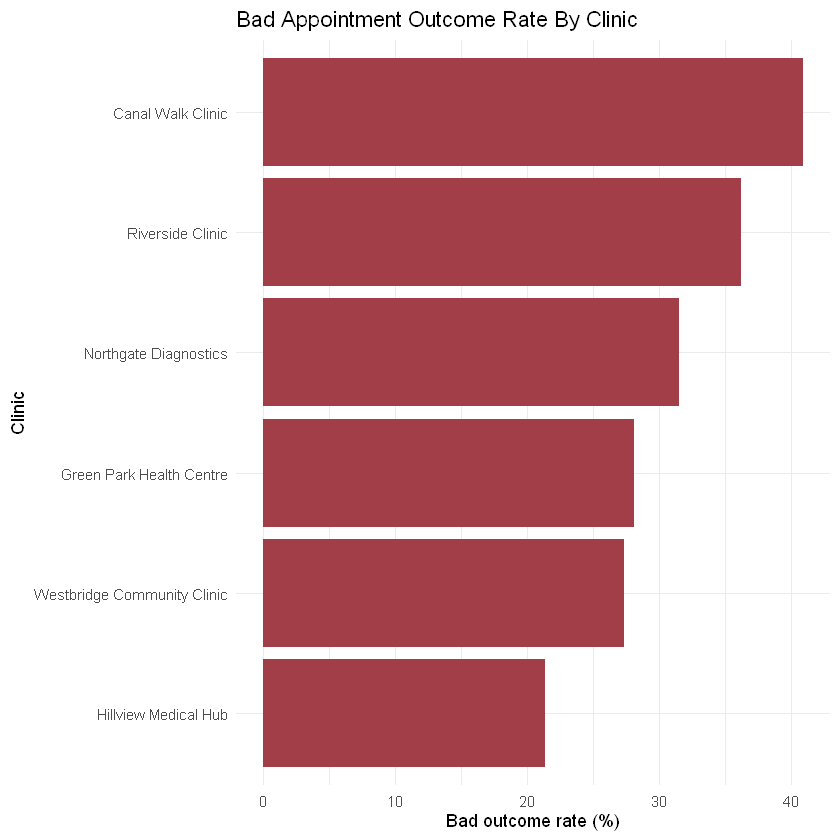

In [5]:
clinic_performance_sql <- "
SELECT
  c.clinic_id,
  c.clinic_name,
  COUNT(a.appointment_id) AS appointments,
  SUM(CASE WHEN a.status IN ('Cancelled by patient', 'Cancelled by clinic', 'No-show') THEN 1 ELSE 0 END) AS bad_outcomes,
  ROUND(SUM(CASE WHEN a.status IN ('Cancelled by patient', 'Cancelled by clinic', 'No-show') THEN 1 ELSE 0 END) * 100.0 / COUNT(a.appointment_id), 2) AS bad_outcome_rate,
  ROUND(AVG(a.waiting_days), 2) AS avg_waiting_days
FROM appointments a
JOIN clinics c ON a.clinic_id = c.clinic_id
GROUP BY c.clinic_id, c.clinic_name
ORDER BY bad_outcome_rate DESC;
"
clinic_performance <- dbGetQuery(con, clinic_performance_sql)
write_csv(clinic_performance, file.path(table_dir, "r_sql_clinic_performance.csv"))
print(clinic_performance)

p_clinic <- ggplot(clinic_performance, aes(x = reorder(clinic_name, bad_outcome_rate), y = bad_outcome_rate)) +
  geom_col(fill = "#a23e48") +
  coord_flip() +
  labs(title = "Bad Appointment Outcome Rate By Clinic", x = "Clinic", y = "Bad outcome rate (%)") +
  theme_minimal()
ggsave(file.path(fig_dir, "r_bad_outcome_by_clinic.png"), p_clinic, width = 8, height = 5, dpi = 150)
print(p_clinic)

## 6. SQL Waiting Time By Service

This SQL query compares appointment waiting days across service types.

In [6]:
service_wait_sql <- "
SELECT
  service_type,
  COUNT(*) AS appointments,
  ROUND(AVG(waiting_days), 2) AS avg_waiting_days,
  MAX(waiting_days) AS max_waiting_days
FROM appointments
GROUP BY service_type
ORDER BY avg_waiting_days DESC;
"
service_wait <- dbGetQuery(con, service_wait_sql)
write_csv(service_wait, file.path(table_dir, "r_sql_waiting_by_service.csv"))
service_wait

service_type,appointments,avg_waiting_days,max_waiting_days
<chr>,<int>,<dbl>,<dbl>
Blood Test,111,13.53,28
GP Consultation,104,13.32,28
Community Follow-up,119,13.32,27
Diagnostic Scan,123,13.01,28
Nurse Appointment,117,12.57,28
Prescription Review,126,11.37,28


## 7. SQL Referral Delay Analysis

This SQL query identifies referral services with the highest open or delayed referral rate.

In [7]:
referral_sql <- "
SELECT
  target_service,
  COUNT(*) AS referrals,
  SUM(CASE WHEN referral_status IN ('Open', 'Delayed') THEN 1 ELSE 0 END) AS open_or_delayed,
  ROUND(SUM(CASE WHEN referral_status IN ('Open', 'Delayed') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS open_or_delayed_rate,
  ROUND(AVG(days_open), 2) AS avg_days_open
FROM referrals
GROUP BY target_service
ORDER BY open_or_delayed_rate DESC;
"
referral_delay <- dbGetQuery(con, referral_sql)
write_csv(referral_delay, file.path(table_dir, "r_sql_referral_delay.csv"))
referral_delay

target_service,referrals,open_or_delayed,open_or_delayed_rate,avg_days_open
<chr>,<int>,<int>,<dbl>,<dbl>
Cardiology,45,23,51.11,23.09
Community Nursing,53,25,47.17,27.70
Physiotherapy,38,17,44.74,25.47
Dermatology,42,16,38.10,23.24
Diagnostics,35,11,31.43,26.43
Mental Health,37,11,29.73,26.19


## 8. SQL Prescription Delay Analysis

This SQL query checks prescription processing delay by clinic.

In [8]:
prescription_sql <- "
SELECT
  c.clinic_name,
  COUNT(p.prescription_id) AS prescriptions,
  SUM(CASE WHEN p.processing_days > 3 THEN 1 ELSE 0 END) AS delayed_count,
  ROUND(SUM(CASE WHEN p.processing_days > 3 THEN 1 ELSE 0 END) * 100.0 / COUNT(p.prescription_id), 2) AS delayed_rate,
  ROUND(AVG(p.processing_days), 2) AS avg_processing_days
FROM prescriptions p
JOIN clinics c ON p.clinic_id = c.clinic_id
GROUP BY c.clinic_name
ORDER BY delayed_rate DESC;
"
prescription_delay <- dbGetQuery(con, prescription_sql)
write_csv(prescription_delay, file.path(table_dir, "r_sql_prescription_delay.csv"))
prescription_delay

clinic_name,prescriptions,delayed_count,delayed_rate,avg_processing_days
<chr>,<int>,<int>,<dbl>,<dbl>
Green Park Health Centre,46,13,28.26,2.37
Hillview Medical Hub,78,18,23.08,2.35
Northgate Diagnostics,80,17,21.25,2.15
Riverside Clinic,66,14,21.21,2.27
Westbridge Community Clinic,64,12,18.75,2.50
Canal Walk Clinic,66,12,18.18,2.24


## 9. SQL INSERT Example

This cell demonstrates an SQL INSERT operation using a small demo table, so the original dataset is not damaged.

In [9]:
invisible(dbExecute(con, "DROP TABLE IF EXISTS appointment_demo;"))
invisible(dbExecute(con, "CREATE TABLE appointment_demo AS SELECT * FROM appointments WHERE 1 = 0;"))
invisible(dbExecute(con, "
INSERT INTO appointment_demo
SELECT * FROM appointments
WHERE appointment_id = 'A0001';
"))
insert_result <- dbGetQuery(con, "SELECT appointment_id, patient_id, clinic_id, status FROM appointment_demo;")
insert_result

appointment_id,patient_id,clinic_id,status
<chr>,<chr>,<chr>,<chr>


## 10. SQL UPDATE Example

This cell demonstrates an SQL UPDATE operation on the demo record.

In [10]:
invisible(dbExecute(con, "UPDATE appointment_demo SET status = 'Rescheduled' WHERE appointment_id = 'A0001';"))
update_result <- dbGetQuery(con, "SELECT appointment_id, status FROM appointment_demo;")
update_result

appointment_id,status
<chr>,<chr>


## 11. SQL DELETE Example

This cell demonstrates an SQL DELETE operation on the demo record.

In [11]:
invisible(dbExecute(con, "DELETE FROM appointment_demo WHERE appointment_id = 'A0001';"))
delete_result <- dbGetQuery(con, "SELECT COUNT(*) AS rows_after_delete FROM appointment_demo;")
delete_result

rows_after_delete
<int>
0


## 12. SQL Query Optimisation Check

This cell creates an index and uses SQLite `EXPLAIN QUERY PLAN` to show the query plan before and after indexing.

In [12]:
invisible(dbExecute(con, "DROP INDEX IF EXISTS idx_appointments_clinic_status;"))
explain_before <- dbGetQuery(con, "EXPLAIN QUERY PLAN SELECT * FROM appointments WHERE clinic_id = 'CL006' AND status = 'No-show';")

invisible(dbExecute(con, "CREATE INDEX idx_appointments_clinic_status ON appointments(clinic_id, status);"))
explain_after <- dbGetQuery(con, "EXPLAIN QUERY PLAN SELECT * FROM appointments WHERE clinic_id = 'CL006' AND status = 'No-show';")

write_csv(explain_before, file.path(table_dir, "r_sql_explain_before.csv"))
write_csv(explain_after, file.path(table_dir, "r_sql_explain_after.csv"))

list(before_index = explain_before, after_index = explain_after)

id,parent,notused,detail
<int>,<int>,<int>,<chr>
2,0,216,SCAN appointments
id,parent,notused,detail
<int>,<int>,<int>,<chr>
3,0,61,SEARCH appointments USING INDEX idx_appointments_clinic_status (clinic_id=? AND status=?)


## 13. R Analytics Summary

This cell uses R data manipulation to summarise feedback, complaints and the relationship between waiting days and rating.

In [13]:
feedback_r <- patient_feedback %>%
  inner_join(appointments %>% select(appointment_id, status, waiting_days, service_type), by = "appointment_id") %>%
  inner_join(clinics %>% select(clinic_id, clinic_name), by = "clinic_id")

analytics_summary <- feedback_r %>%
  summarise(
    avg_rating = mean(rating, na.rm = TRUE),
    complaint_rate = mean(complaint_flag, na.rm = TRUE) * 100,
    wait_rating_correlation = cor(waiting_days, rating, use = "complete.obs")
  )
write_csv(analytics_summary, file.path(table_dir, "r_analytics_summary.csv"))
analytics_summary

Warning message:
"There was 1 warning in `summarise()`.
ℹ In argument: `complaint_rate = mean(complaint_flag, na.rm = TRUE) * 100`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA"


avg_rating,complaint_rate,wait_rating_correlation
<dbl>,<dbl>,<dbl>
3.057143,NA,-0.2908511


## 14. R Analytics - Feedback By Status

This R analysis compares patient ratings and complaint rates by appointment status, then visualises the average rating.

Warning message:
"There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `complaint_rate = mean(complaint_flag, na.rm = TRUE) * 100`.
ℹ In group 1: `status = "Cancelled by clinic"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings."


# A tibble: 5 × 4
  status               feedback_count avg_rating complaint_rate
  <chr>                         <int>      <dbl>          <dbl>
1 No-show                          28       2.04             NA
2 Rescheduled                      22       2.23             NA
3 Cancelled by clinic              45       2.27             NA
4 Cancelled by patient             48       2.62             NA
5 Completed                       207       3.56             NA


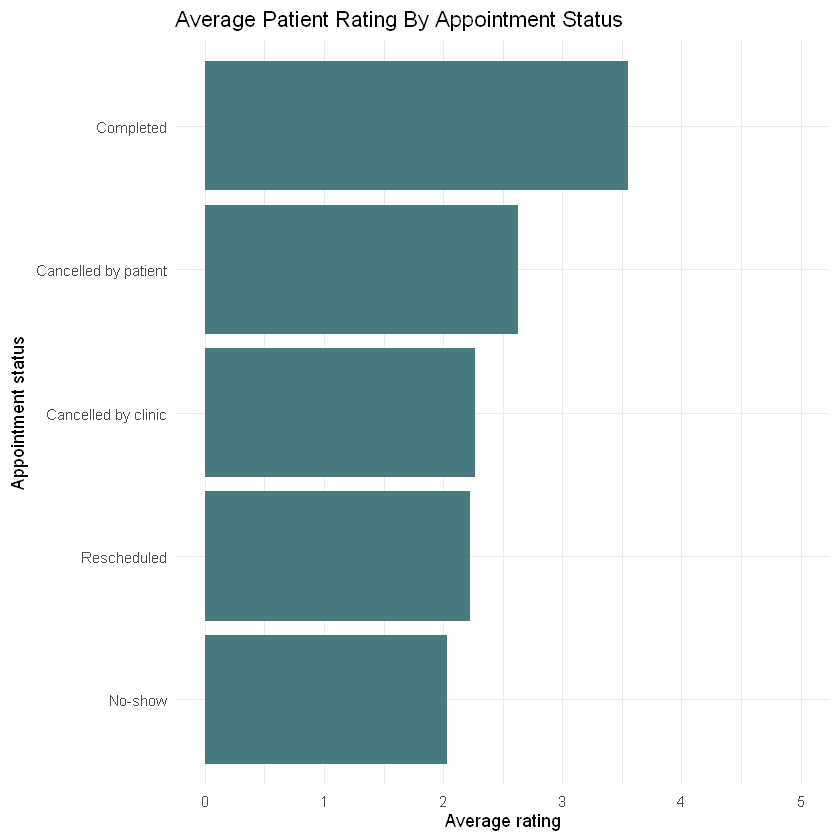

In [14]:
feedback_status <- feedback_r %>%
  group_by(status) %>%
  summarise(
    feedback_count = n(),
    avg_rating = mean(rating, na.rm = TRUE),
    complaint_rate = mean(complaint_flag, na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  arrange(avg_rating)
write_csv(feedback_status, file.path(table_dir, "r_analytics_feedback_status.csv"))
print(feedback_status)

p_rating <- ggplot(feedback_status, aes(x = reorder(status, avg_rating), y = avg_rating)) +
  geom_col(fill = "#487b7f") +
  coord_flip() +
  labs(title = "Average Patient Rating By Appointment Status", x = "Appointment status", y = "Average rating") +
  ylim(0, 5) +
  theme_minimal()
ggsave(file.path(fig_dir, "r_rating_by_status.png"), p_rating, width = 8, height = 5, dpi = 150)
print(p_rating)

## 15. R Analytics - Waiting Days And Rating

This chart checks whether longer appointment waiting time is linked with lower patient rating.

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


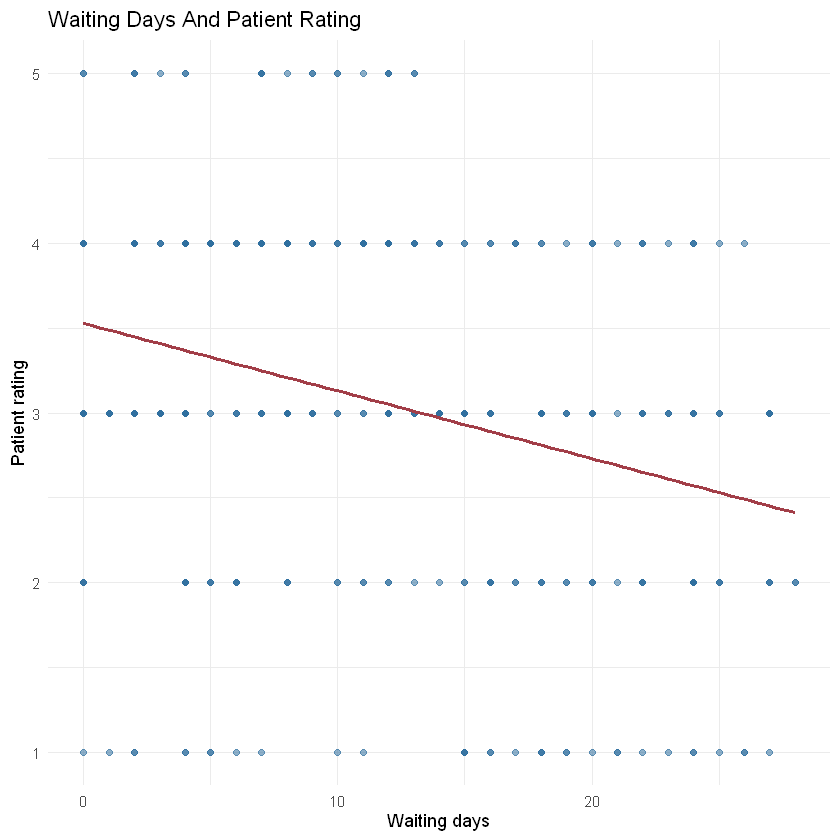

In [15]:
p_wait <- ggplot(feedback_r, aes(x = waiting_days, y = rating)) +
  geom_point(alpha = 0.55, colour = "#2f6f9f") +
  geom_smooth(method = "lm", se = FALSE, colour = "#a23e48") +
  labs(title = "Waiting Days And Patient Rating", x = "Waiting days", y = "Patient rating") +
  theme_minimal()
ggsave(file.path(fig_dir, "r_waiting_days_vs_rating.png"), p_wait, width = 8, height = 5, dpi = 150)
print(p_wait)

## 16. R Analytics - Nurse Visit Problems

This R analysis checks nurse visit problem rates by clinic, supporting the case study issue of community nurse scheduling.

# A tibble: 6 × 6
  clinic_id clinic_name                 visits problem_visits problem_visit_rate
  <chr>     <chr>                        <int>          <int>              <dbl>
1 CL004     Westbridge Community Clinic     83             37               44.6
2 CL001     Riverside Clinic                76             32               42.1
3 CL006     Canal Walk Clinic               51             20               39.2
4 CL003     Northgate Diagnostics           30             10               33.3
5 CL005     Hillview Medical Hub            33             11               33.3
6 CL002     Green Park Health Centre        27              8               29.6
# ℹ 1 more variable: avg_arrival_delay_min <dbl>


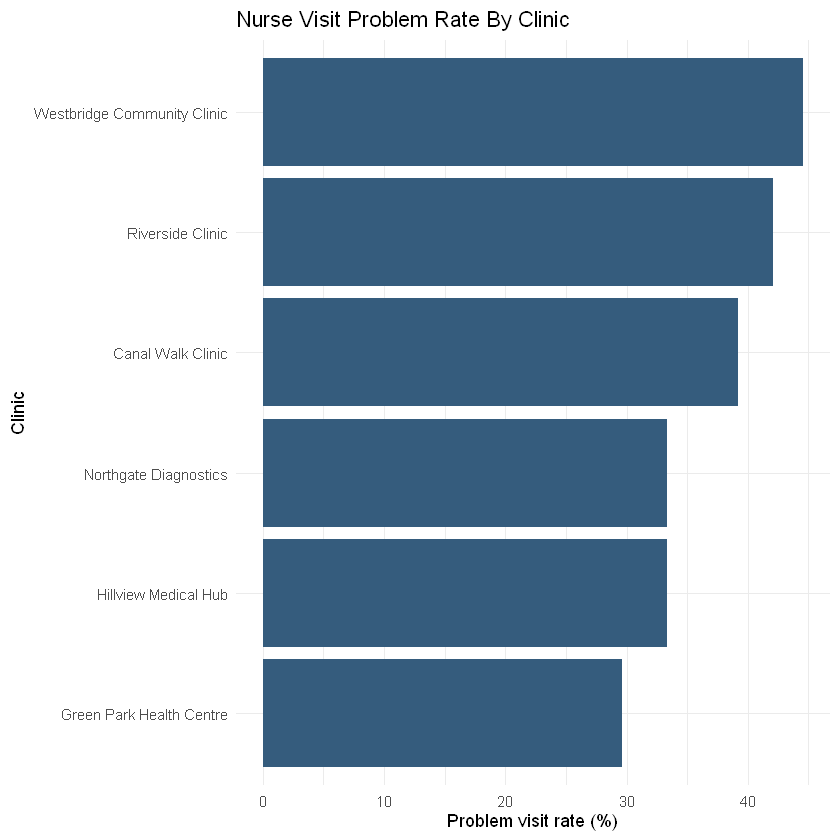

In [16]:
nurse_clinic <- nurse_visits %>%
  mutate(
    follow_up_required_flag = tolower(as.character(follow_up_required)) == "true",
    follow_up_required_flag = if_else(is.na(follow_up_required_flag), FALSE, follow_up_required_flag),
    problem_visit = visit_status != "Completed" | follow_up_required_flag
  ) %>%
  inner_join(clinics %>% select(clinic_id, clinic_name), by = "clinic_id") %>%
  group_by(clinic_id, clinic_name) %>%
  summarise(
    visits = n(),
    problem_visits = sum(problem_visit, na.rm = TRUE),
    problem_visit_rate = problem_visits / visits * 100,
    avg_arrival_delay_min = mean(arrival_delay_min, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(problem_visit_rate))
write_csv(nurse_clinic, file.path(table_dir, "r_analytics_nurse_clinic.csv"))
print(nurse_clinic)

p_nurse <- ggplot(nurse_clinic, aes(x = reorder(clinic_name, problem_visit_rate), y = problem_visit_rate)) +
  geom_col(fill = "#355c7d") +
  coord_flip() +
  labs(title = "Nurse Visit Problem Rate By Clinic", x = "Clinic", y = "Problem visit rate (%)") +
  theme_minimal()
ggsave(file.path(fig_dir, "r_nurse_visit_problem_by_clinic.png"), p_nurse, width = 8, height = 5, dpi = 150)
print(p_nurse)